## Goal of this notebook 

(Following module 3 of https://ml-learn.mds.ubc.ca/en/)

- Split a dataset into train and test sets using train_test_split function.
- Explain the difference between train, validation, test, and "deployment" data.
- Identify the difference between training error, validation error, and test error.
- Explain cross-validation and use cross_val_score() and cross_validate() to calculate cross-validation error.
- Explain overfitting, underfitting, and the fundamental tradeoff.
- State the golden rule and identify the scenarios when it's violated.

In [1]:
import pandas as pd

In [2]:
cities_df = pd.read_csv("../Data/canada_usa_cities.csv")
cities_df = cities_df.drop(columns=["Unnamed: 0"])
cities_df

,longitude,latitude,country
0,-69.7487,42.7266,USA
1,-115.6821,28.3843,USA
2,-74.6350,39.4678,USA
3,-139.1803,81.8543,Canada
4,-122.2292,49.2276,Canada
...,...,...,...
995,-136.4325,62.5985,Canada
996,-64.7426,49.1212,Canada
997,-92.1407,58.1173,Canada
998,-74.6859,28.4161,USA


In [3]:
X = cities_df.drop(columns='country')
y = cities_df['country']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,longitude,latitude
29,-62.5704,61.2497
535,-120.7920,44.4289
695,-118.6036,40.8538
557,-64.2638,75.0653
836,-62.0508,44.2857


In [15]:
#alternative way to split dataset
train_df, test_df = train_test_split(cities_df, test_size=0.2)

X_train, y_train = train_df.drop(columns=["country"]), train_df["country"]
X_test, y_test = test_df.drop(columns=["country"]), test_df["country"]
train_df

,longitude,latitude,country
454,-85.1701,72.0509,Canada
803,-84.9177,27.9998,USA
704,-73.0274,40.7919,USA
282,-67.0807,37.0047,USA
426,-95.8643,39.8921,USA
...,...,...,...
253,-127.5919,54.6053,Canada
589,-102.9737,34.3225,USA
436,-77.6031,26.4949,USA
753,-79.9698,39.4879,USA


Because we kept features and targets in same dataset, can easily visualize

In [16]:
import plotly.express as px
fig = px.scatter_geo(train_df, lat='latitude', lon='longitude', color='country')
fig.show()

In [17]:
fig = px.scatter_geo(test_df, lat='latitude', lon='longitude', color='country')
fig.show()

Other library for visualization

In [18]:
import altair as alt

chart_cities = alt.Chart(train_df).mark_circle(size=20, opacity=0.6).encode(
    alt.X('longitude:Q', scale=alt.Scale(domain=[-140, -40])),
    alt.Y('latitude:Q', scale=alt.Scale(domain=[20, 100])),
    alt.Color('country:N', scale=alt.Scale(domain=['Canada','USA'], range=['red','blue'])))
chart_cities

alt.Chart(...)

Build model by constructing decision tree classifier and fitting it

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(max_depth=69)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",69
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

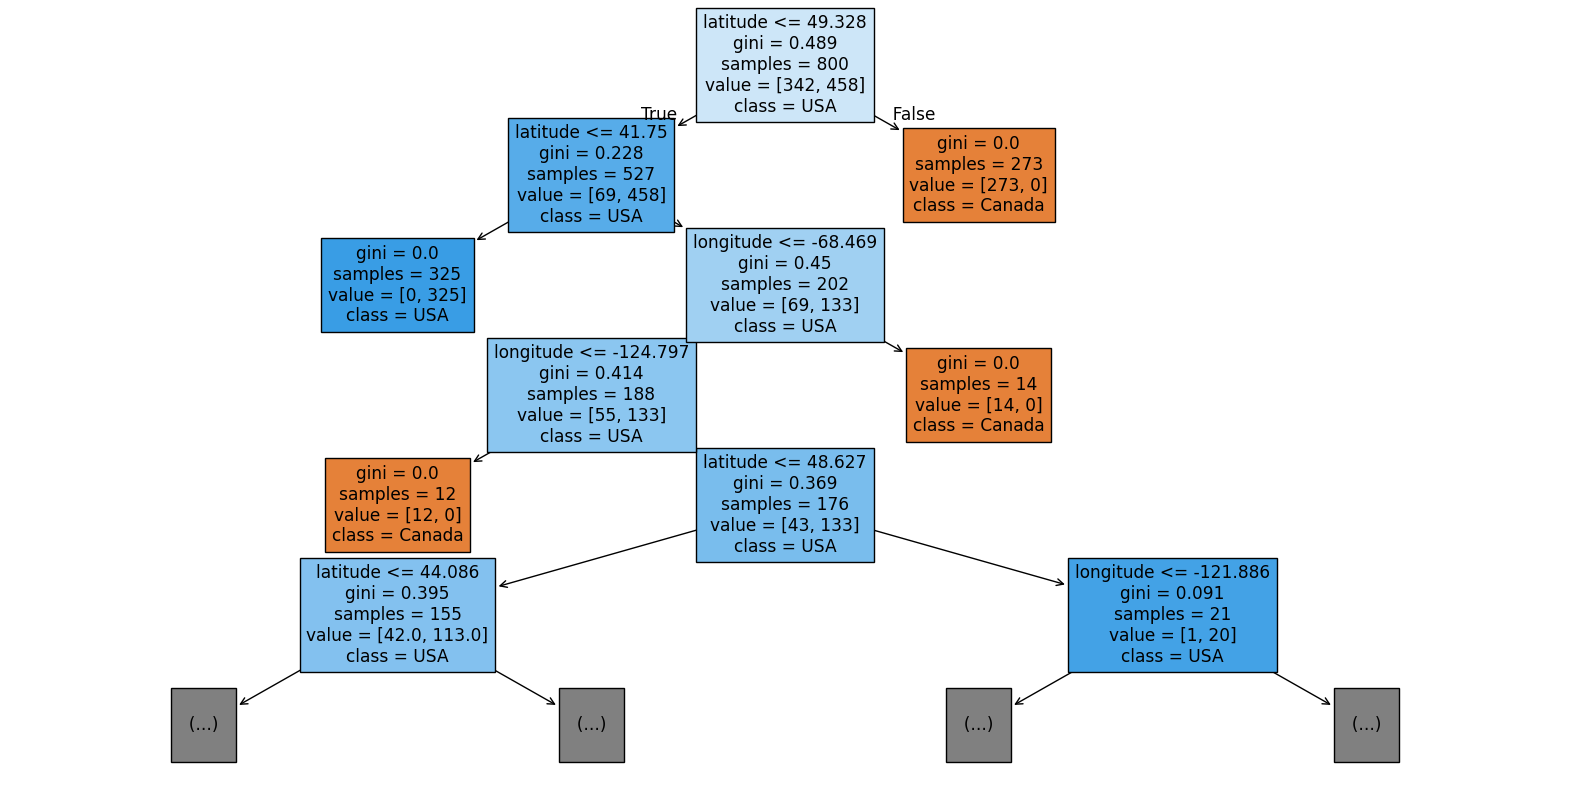

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model, max_depth=5, filled=True, feature_names=X.columns, class_names=model.classes_)
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


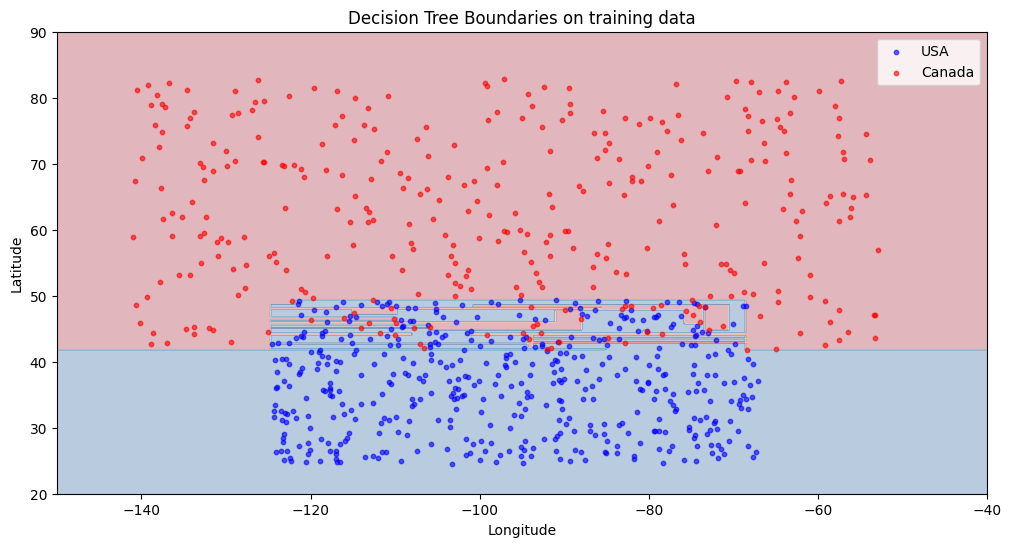

In [21]:
import numpy as np

# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = train_df['country'] == country
    plt.scatter(train_df[mask]['longitude'], train_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Decision Tree Boundaries on training data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


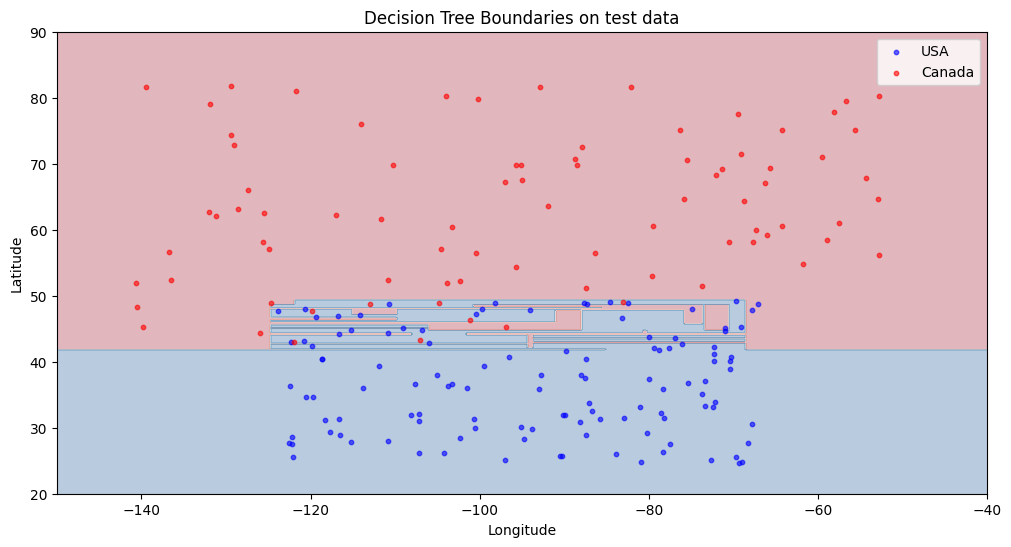

In [22]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = test_df['country'] == country
    plt.scatter(test_df[mask]['longitude'], test_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Decision Tree Boundaries on test data')
plt.show()

In [23]:
print(f"Train score: {(round(model.score(X_train, y_train), 5))}")
print(f"Test score: {(round(model.score(X_test, y_test), 5))}")

Train score: 1.0
Test score: 0.925


Model does perfect on training data, but not as well on testing data. Here we have an example of overfitting, even though in this case it still does very well on test data. Test data is probably too similar to training data. 

### Cross-validation

In [26]:
X = cities_df.drop(columns='country')
y = cities_df['country']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(max_depth=4)
cv_score = cross_val_score(model, X_train, y_train, cv=5)
cv_score

array([0.95   , 0.95   , 0.9375 , 0.94375, 0.9    ])

In [27]:
cv_score = cross_val_score(model, X_train, y_train, cv=10)
cv_score

array([0.9375, 0.9625, 0.975 , 0.925 , 0.875 , 1.    , 0.95  , 0.9375,
       0.9   , 0.9   ])

In [28]:
cv_score.mean()

np.float64(0.93625)

In [30]:
from sklearn.model_selection import cross_validate

scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
scores

{'fit_time': array([0.00472569, 0.00287199, 0.00248623, 0.00196218, 0.00188184,
        0.0018568 , 0.00179887, 0.0018084 , 0.00178146, 0.00187182]),
 'score_time': array([0.00310755, 0.00182271, 0.00126743, 0.00125504, 0.00116992,
        0.0011363 , 0.00111246, 0.00115085, 0.00113869, 0.00115275]),
 'test_score': array([0.9375, 0.9625, 0.975 , 0.925 , 0.875 , 1.    , 0.95  , 0.9375,
        0.9   , 0.9   ]),
 'train_score': array([0.94444444, 0.94305556, 0.94166667, 0.94583333, 0.95      ,
        0.93888889, 0.94444444, 0.94444444, 0.95      , 0.94861111])}

In [31]:
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.004726,0.003108,0.9375,0.944444
1,0.002872,0.001823,0.9625,0.943056
2,0.002486,0.001267,0.9750,0.941667
3,0.001962,0.001255,0.9250,0.945833
4,0.001882,0.001170,0.8750,0.950000
5,0.001857,0.001136,1.0000,0.938889
6,0.001799,0.001112,0.9500,0.944444
7,0.001808,0.001151,0.9375,0.944444
8,0.001781,0.001139,0.9000,0.950000
9,0.001872,0.001153,0.9000,0.948611


In [33]:
scores['train_score'].mean(), scores['test_score'].mean()

(np.float64(0.9451388888888888), np.float64(0.93625))

In [34]:
scores['train_score'].std(), scores['test_score'].std()

(np.float64(0.003416214965624667), np.float64(0.035990450122219915))

#### Types of scores

- score_train: training score, i.e. mean train score from cross-validation, score model gets on the same data it was trained on.
- score_validation: validation score, i.e. mean validation score from cross-validation
- score_test: score from unseen data

#### How to choose the best hyperparameters (here tree depth)?

In [36]:
results_dict = {
    "depth": list(),
    "mean_train_score": list(),
    "mean_cv_score": list()
                }

for depth in range(1, 20):

    model = DecisionTreeClassifier(max_depth=depth)

    scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)

    results_dict['depth'].append(depth)
    results_dict['mean_train_score'].append(scores['train_score'].mean())
    results_dict['mean_cv_score'].append(scores['test_score'].mean())


df_scores = pd.DataFrame(results_dict)
df_scores

,depth,mean_train_score,mean_cv_score
0,1,0.913750,0.91125
1,2,0.913750,0.91125
2,3,0.930833,0.91375
3,4,0.945139,0.93625
4,5,0.945833,0.93625
5,6,0.947639,0.93250
6,7,0.950972,0.93000
7,8,0.954306,0.92750
8,9,0.958750,0.92625
9,10,0.962778,0.92625


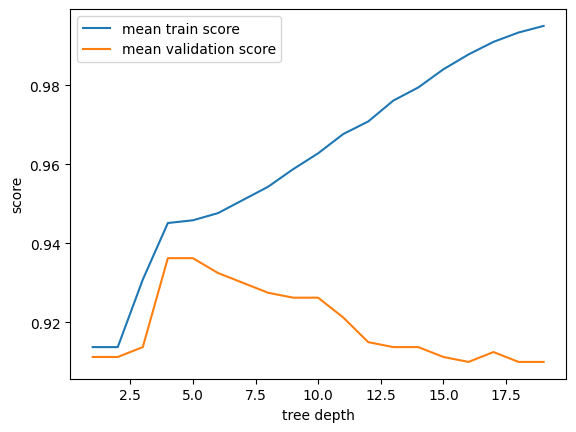

In [42]:
plt.plot(df_scores['depth'], df_scores['mean_train_score'], label='mean train score')
plt.plot(df_scores['depth'], df_scores['mean_cv_score'], label='mean validation score')
plt.xlabel('tree depth')
plt.ylabel('score')
plt.legend()

In [43]:
df_scores.sort_values('mean_cv_score', ascending=False)

,depth,mean_train_score,mean_cv_score
3,4,0.945139,0.93625
4,5,0.945833,0.93625
5,6,0.947639,0.93250
6,7,0.950972,0.93000
7,8,0.954306,0.92750
9,10,0.962778,0.92625
8,9,0.958750,0.92625
10,11,0.967639,0.92125
11,12,0.970833,0.91500
2,3,0.930833,0.91375


In [44]:
df_scores.sort_values('mean_cv_score', ascending=False).iloc[0]

depth               4.000000
mean_train_score    0.945139
mean_cv_score       0.936250
Name: 3, dtype: float64

In [45]:
best_depth = df_scores.sort_values('mean_cv_score', ascending=False).iloc[0]['depth']
best_depth

np.float64(4.0)

Now that we found the best depth, we can test our model

In [50]:
model = DecisionTreeClassifier(max_depth=int(best_depth)) #use best depth from our cross-validation
model.fit(X_train, y_train) # fit train set
test_score = model.score(X_test, y_test) # evaluate result on test set  (score does both predict() and score())
test_score

0.96

### The golden rule

The test data **cannot** influence the training phase in any way! 

Always follow these steps: 
1. Splitting: before doing anything always split data X, y into X_train, X_test, y_train and y_test
2. Select the best model (best hyperparameters) using cross-validation: Use `cross_validate` with `return_score = True`, so that we can access the training scores in each fold. Can plot train vs validation error plots for ex.
3. Scoring on test data: Finally score on test data with chosen best hyperparameters to examine generalization performance. 